# AutoScout24 Used-Car Price Prediction — EDA & Preprocessing

**Project:** ZHAW AI-Applications — Used-Car Price Prediction  
**Block:** ML Numeric (Step 1 of 3)  
**Date:** 2026-06-02  

**Scope:** EDA, data cleaning, and feature engineering only. No models trained.  
**Output:** `data/autoscout_clean.csv`  
**Target variable:** `price` (listing price in EUR)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

DATA_DIR     = Path('../data')
RAW_CSV      = DATA_DIR / 'autoscout24_dataset_20251108.csv'
CLEAN_CSV    = DATA_DIR / 'autoscout_clean.csv'
CURRENT_YEAR = 2026
print('Libraries loaded. CURRENT_YEAR =', CURRENT_YEAR)

Libraries loaded. CURRENT_YEAR = 2026


## 1. Load & First Look

In [2]:
df_raw = pd.read_csv(RAW_CSV, low_memory=False)
print(f'Shape : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'Memory: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Shape : 118,382 rows x 75 columns
Memory: 961.7 MB


In [3]:
df_raw.head(3)

,id,description,ratings_average,ratings_count,ratings_recommend_percentage,price_currency,price,price_tax_deductible,price_negotiable,price_net,...,zip,city,street,latitude,longitude,seller_is_dealer,seller_type,seller_company_name,has_warranty,warranty
0,001c08bb-96f9-4198-a2c9-39bcab088a08,"Deze Suzuki Swift is maatje S, maar hij valt e...",NaN,NaN,NaN,EUR,22950.0,True,False,19279.0,...,8801 PN,FRANEKER,Edisonstraat 1,53.18188,5.52596,True,Dealer,Haaima Franeker,NaN,NaN
1,00918c06-f736-404a-b55a-0ccd1d876129,"Kraftvoll, komfortabel, kompromisslos: BMW X3 ...",NaN,NaN,NaN,EUR,46000.0,False,False,NaN,...,81476,München,NaN,48.09126,11.49140,False,PrivateSeller,NaN,NaN,NaN
2,0083e29f-8030-4478-b662-6dff92e22a06,<strong>Highlights:</strong><br /><ul><li><str...,"4,8",124.0,0.0,EUR,179900.0,False,False,NaN,...,9830,Sint-Martens-Latem,Kortrijksesteenweg 168,51.00730,3.62822,True,Dealer,Garage Vandenberghe,NaN,NaN


In [4]:
# --- Parse string columns that contain numeric values with units ---
# e.g. mileage_km = '10,500 km', weight_kg = '894 kg', ratings_average = '4,8'

def strip_unit_to_float(series):
    return (series.astype(str)
                  .str.replace(r'[^\d.,]', '', regex=True)
                  .str.replace(r',(\d{3})', r'\1', regex=True)
                  .str.replace(',', '.', regex=False)
                  .replace('', np.nan)
                  .pipe(pd.to_numeric, errors='coerce'))

for col in ['mileage_km', 'weight_kg']:
    if col in df_raw.columns and df_raw[col].dtype == object:
        df_raw[col] = strip_unit_to_float(df_raw[col])
        print(f'Coerced {col} -> numeric')

if 'ratings_average' in df_raw.columns and df_raw['ratings_average'].dtype == object:
    df_raw['ratings_average'] = (df_raw['ratings_average']
                                 .astype(str).str.replace(',', '.', regex=False)
                                 .pipe(pd.to_numeric, errors='coerce'))
    print('Coerced ratings_average -> numeric')

# --- Extract production_year from registration_date where missing ---
# production_year is only filled for ~22 k rows; registration_date covers ~118 k
if 'registration_date' in df_raw.columns:
    reg_year = pd.to_datetime(df_raw['registration_date'], errors='coerce').dt.year
    mask = df_raw['production_year'].isna() & reg_year.notna()
    df_raw.loc[mask, 'production_year'] = reg_year[mask]
    print(f'Filled {mask.sum():,} missing production_year values from registration_date')

print(f'production_year non-null: {df_raw["production_year"].notna().sum():,}')

Coerced mileage_km -> numeric
Coerced weight_kg -> numeric
Coerced ratings_average -> numeric


Filled 95,954 missing production_year values from registration_date
production_year non-null: 118,226


In [5]:
print(df_raw.dtypes.to_string())

id                                       object
description                              object
ratings_average                         float64
ratings_count                           float64
ratings_recommend_percentage            float64
price_currency                           object
price                                   float64
price_tax_deductible                       bool
price_negotiable                           bool
price_net                               float64
price_vat_rate                          float64
vin                                      object
make                                     object
model                                    object
model_version                            object
german_hsn_tsn                           object
mileage_km_raw                          float64
mileage_km                              float64
registration_date                        object
production_year                         float64
vehicle_type                            

In [6]:
df_raw.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
ratings_average,76428.0,4.00,1.33,0.00,4.00,4.40,4.70,5.00
ratings_count,76428.0,107.13,281.95,0.00,7.00,32.00,95.00,8993.00
ratings_recommend_percentage,76428.0,73.57,35.68,0.00,75.00,89.00,97.00,100.00
price,118382.0,57515.98,109985.84,1.00,23990.00,39980.00,69950.00,13500000.00
price_net,34016.0,57172.74,90534.57,1.00,30555.00,46210.00,67187.25,7250000.00
price_vat_rate,30379.0,18.84,3.17,0.00,19.00,19.00,19.00,22.00
mileage_km_raw,117738.0,71676.62,70648.60,0.00,10000.00,56400.00,111231.75,2570000.00
mileage_km,117738.0,71676.62,70648.60,0.00,10000.00,56400.00,111231.75,2570000.00
production_year,118226.0,2019.82,5.64,1929.00,2018.00,2021.00,2025.00,2026.00
nr_seats,113476.0,4.74,1.40,1.00,5.00,5.00,5.00,255.00


In [7]:
missing = pd.DataFrame({
    'missing_count': df_raw.isna().sum(),
    'missing_pct':   (df_raw.isna().mean() * 100).round(2)
}).sort_values('missing_pct', ascending=False)
print(missing[missing.missing_count > 0].to_string())

                                      missing_count  missing_pct
warranty                                     118382       100.00
has_warranty                                 118382       100.00
fuel_cons_city_l100_km                       118382       100.00
fuel_cons_highway_l100_km                    118382       100.00
electric_range_city_km                       117743        99.46
fuel_cons_electric_comb_l100_wltp_km         113456        95.84
electric_range_km                            105637        89.23
co2_emission_grper_km                         93571        79.04
fuel_cons_comb_l100_wltp_km                   88112        74.43
price_vat_rate                                88003        74.34
german_hsn_tsn                                87571        73.97
price_net                                     84366        71.27
vin                                           78160        66.02
fuel_cons_comb_l100_km                        76538        64.65
original_market          

## 2. Target Variable (price)

In [8]:
# Currency check
currency_counts = df_raw['price_currency'].value_counts(dropna=False)
print('Currency distribution:')
print(currency_counts.to_string())

dominant_currency = currency_counts.index[0]
n_other = int(currency_counts[currency_counts.index != dominant_currency].sum())
print(f'\nDominant currency : {dominant_currency!r} ({int(currency_counts.iloc[0]):,} rows)')
print(f'Other / missing   : {n_other:,} rows  <- DROPPED (no conversion attempted)')

Currency distribution:
price_currency
EUR    118382

Dominant currency : 'EUR' (118,382 rows)
Other / missing   : 0 rows  <- DROPPED (no conversion attempted)


In [9]:
df = df_raw[df_raw['price_currency'] == dominant_currency].copy()
print(f'Rows after currency filter: {len(df):,}')

Rows after currency filter: 118,382


min  : 1
max  : 13,500,000
mean : 57,516
med  : 39,980
skew : 48.445
null : 0


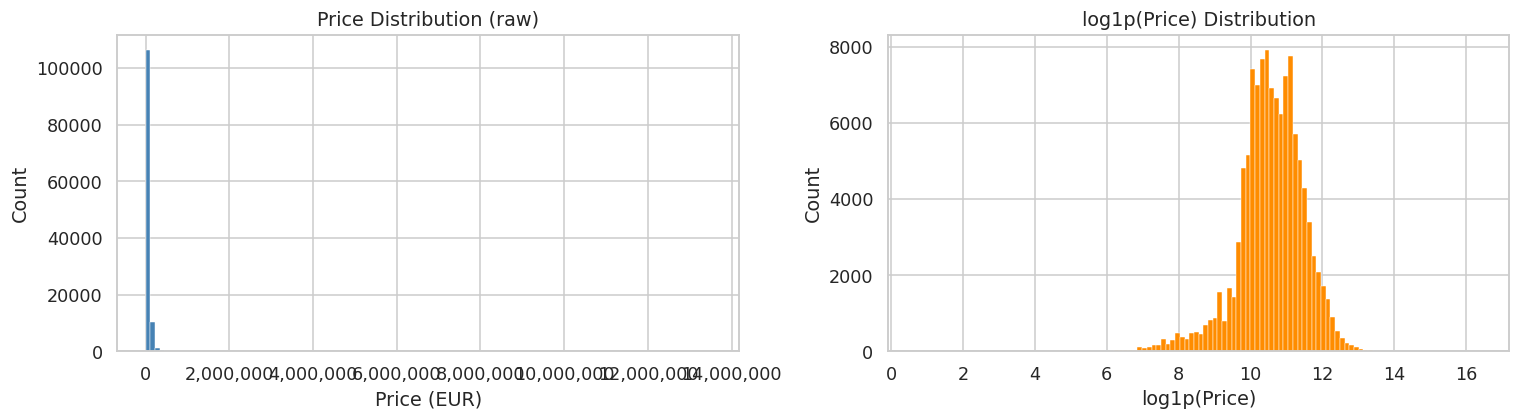

In [10]:
price = df['price'].dropna()
print(f'min  : {price.min():,.0f}')
print(f'max  : {price.max():,.0f}')
print(f'mean : {price.mean():,.0f}')
print(f'med  : {price.median():,.0f}')
print(f'skew : {price.skew():.3f}')
print(f'null : {df["price"].isna().sum():,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(price, bins=120, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Price Distribution (raw)')
axes[0].set_xlabel(f'Price ({dominant_currency})')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[1].hist(np.log1p(price), bins=120, color='darkorange', edgecolor='white', linewidth=0.3)
axes[1].set_title('log1p(Price) Distribution')
axes[1].set_xlabel('log1p(Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [11]:
for t in [0, 100, 500, 1000]:
    print(f'price <= {t:>8,.0f} : {(df["price"] <= t).sum():>6,} rows')
print()
for t in [200_000, 500_000, 1_000_000]:
    print(f'price >= {t:>8,.0f} : {(df["price"] >= t).sum():>6,} rows')

PRICE_LOW, PRICE_HIGH = 500, 150_000
n_outside = int(((df['price'] < PRICE_LOW) | (df['price'] > PRICE_HIGH)).sum())
print(f'\nPlausibility range [{PRICE_LOW:,} - {PRICE_HIGH:,}]')
print(f'Rows outside range : {n_outside:,}  <- dropped in Section 5')

price <=        0 :      0 rows
price <=      100 :      8 rows
price <=      500 :     59 rows
price <=    1,000 :    305 rows

price >=  200,000 :  2,553 rows
price >=  500,000 :    138 rows
price >= 1,000,000 :     54 rows

Plausibility range [500 - 150,000]
Rows outside range : 6,058  <- dropped in Section 5


## 3. Scope Decision: Country

In [12]:
country_counts = df['country_code'].value_counts(dropna=False).reset_index()
country_counts.columns = ['country_code', 'count']
country_counts['pct'] = (country_counts['count'] / len(df) * 100).round(2)
print(country_counts.to_string(index=False))

country_code  count   pct
          DE  45611 38.53
          IT  23957 20.24
          NL  17059 14.41
          BE   9582  8.09
          ES   8015  6.77
          AT   7213  6.09
          FR   6141  5.19
          LU    789  0.67
         NaN     15  0.01


In [13]:
ch_rows = int((df['country_code'] == 'CH').sum())
total   = len(df)
print(f'CH rows : {ch_rows:,}  ({ch_rows/total*100:.1f}%)')
print(f'Non-CH  : {total - ch_rows:,}  ({(total-ch_rows)/total*100:.1f}%)')
print()
if ch_rows >= 5000:
    print('RECOMMENDATION: CH-only subset IS viable (>= 5,000 rows).')
    print('Full European set gives more training data.')
else:
    print('RECOMMENDATION: CH alone has < 5,000 rows -- keep full European set.')
print('FLAG FOR REVIEW: Confirm CH-only vs full Europe before model training.')

CH rows : 0  (0.0%)
Non-CH  : 118,382  (100.0%)

RECOMMENDATION: CH alone has < 5,000 rows -- keep full European set.
FLAG FOR REVIEW: Confirm CH-only vs full Europe before model training.


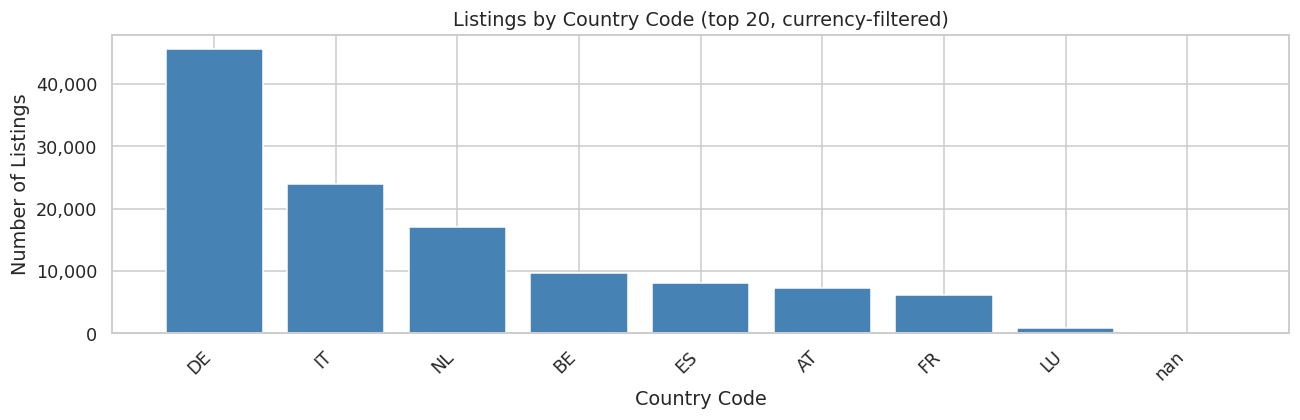

In [14]:
fig, ax = plt.subplots(figsize=(12, 4))
top_c = country_counts.head(20)
ax.bar(top_c['country_code'].astype(str), top_c['count'], color='steelblue')
ax.set_title('Listings by Country Code (top 20, currency-filtered)')
ax.set_xlabel('Country Code')
ax.set_ylabel('Number of Listings')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Feature-by-Feature EDA

### 4a. Numeric features

In [15]:
print('mileage_km:')
print(df['mileage_km'].describe().round(1))
print(f"Zero-mileage (used cars) : {(df['mileage_km'] == 0).sum():,}")
print(f"mileage_km >= 1,000,000  : {(df['mileage_km'] >= 1_000_000).sum():,}")

mileage_km:
count     117738.0
mean       71676.6
std        70648.6
min            0.0
25%        10000.0
50%        56400.0
75%       111231.8
max      2570000.0
Name: mileage_km, dtype: float64
Zero-mileage (used cars) : 246
mileage_km >= 1,000,000  : 4


In [16]:
print('production_year:')
print(df['production_year'].describe().round(0))
print(f"prod_year < 1950       : {(df['production_year'] < 1950).sum():,}")
print(f"prod_year > {CURRENT_YEAR}   : {(df['production_year'] > CURRENT_YEAR).sum():,}")

production_year:
count    118226.0
mean       2020.0
std           6.0
min        1929.0
25%        2018.0
50%        2021.0
75%        2025.0
max        2026.0
Name: production_year, dtype: float64
prod_year < 1950       : 7
prod_year > 2026   : 0


In [17]:
print('power_hp:')
print(df['power_hp'].describe().round(1))
print(f"power_hp <= 0  : {(df['power_hp'] <= 0).sum():,}")
print(f"power_hp > 2000: {(df['power_hp'] > 2000).sum():,}")

power_hp:
count    116770.0
mean        272.3
std         147.1
min           1.0
25%         162.0
50%         231.0
75%         367.0
max       11033.0
Name: power_hp, dtype: float64
power_hp <= 0  : 0
power_hp > 2000: 4


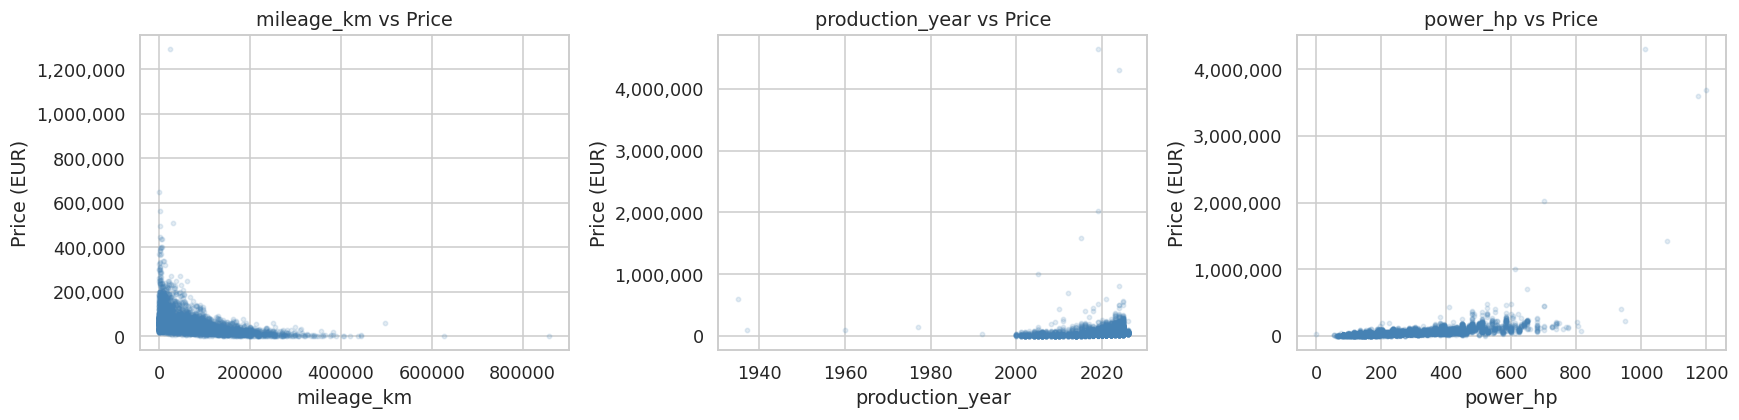

In [18]:
numeric_features = ['mileage_km', 'production_year', 'power_hp']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feat in zip(axes, numeric_features):
    sample = df[[feat, 'price']].dropna().sample(min(5000, len(df)), random_state=RANDOM_STATE)
    ax.scatter(sample[feat], sample['price'], alpha=0.15, s=8, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel(f'Price ({dominant_currency})')
    ax.set_title(f'{feat} vs Price')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

Pearson correlation with price:
mileage_km               -0.231
nr_prev_owners           -0.089
co2_emission_grper_km     0.013
weight_kg                 0.152
production_year           0.157
fuel_cons_comb_l100_km    0.205
cylinders_volume_cc       0.292
power_kw                  0.420
power_hp                  0.420


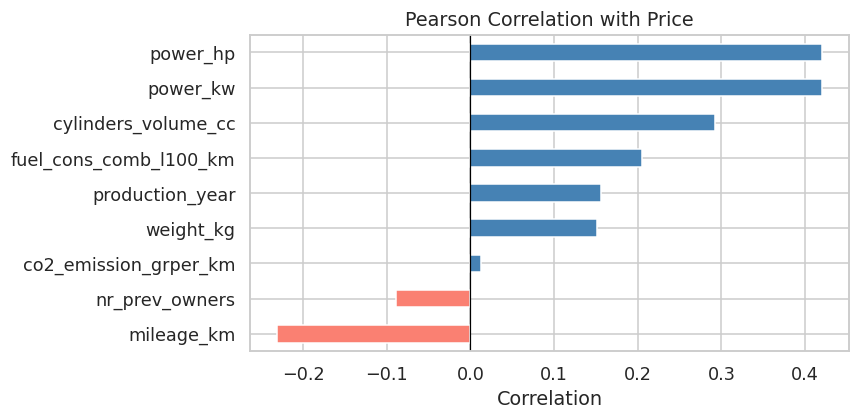

In [19]:
num_cols_corr = ['price', 'mileage_km', 'production_year', 'power_hp', 'power_kw',
                 'cylinders_volume_cc', 'weight_kg', 'fuel_cons_comb_l100_km',
                 'co2_emission_grper_km', 'nr_prev_owners']
num_cols_corr = [c for c in num_cols_corr if c in df.columns]
corr = df[num_cols_corr].corr()['price'].drop('price').sort_values()
print('Pearson correlation with price:')
print(corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
corr.plot(kind='barh', ax=ax, color=['salmon' if v < 0 else 'steelblue' for v in corr])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with Price')
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.show()

### 4b. Categorical features

In [20]:
def cat_price_plot(col, top_n=15, title=None):
    top_cats = df[col].value_counts().head(top_n).index
    subset   = df[df[col].isin(top_cats)]
    agg = subset.groupby(col)['price'].agg(['count', 'median']).reset_index()
    agg.columns = [col, 'count', 'median_price']
    agg = agg.sort_values('median_price', ascending=False)
    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, top_n * 0.35)))
    axes[0].barh(agg[col].astype(str), agg['count'], color='steelblue')
    axes[0].set_title(f'{col} - Count'); axes[0].set_xlabel('Count'); axes[0].invert_yaxis()
    axes[1].barh(agg[col].astype(str), agg['median_price'], color='darkorange')
    axes[1].set_title(f'{col} - Median Price')
    axes[1].set_xlabel(f'Median Price ({dominant_currency})')
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    axes[1].invert_yaxis()
    plt.suptitle(title or col, fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()
    return agg

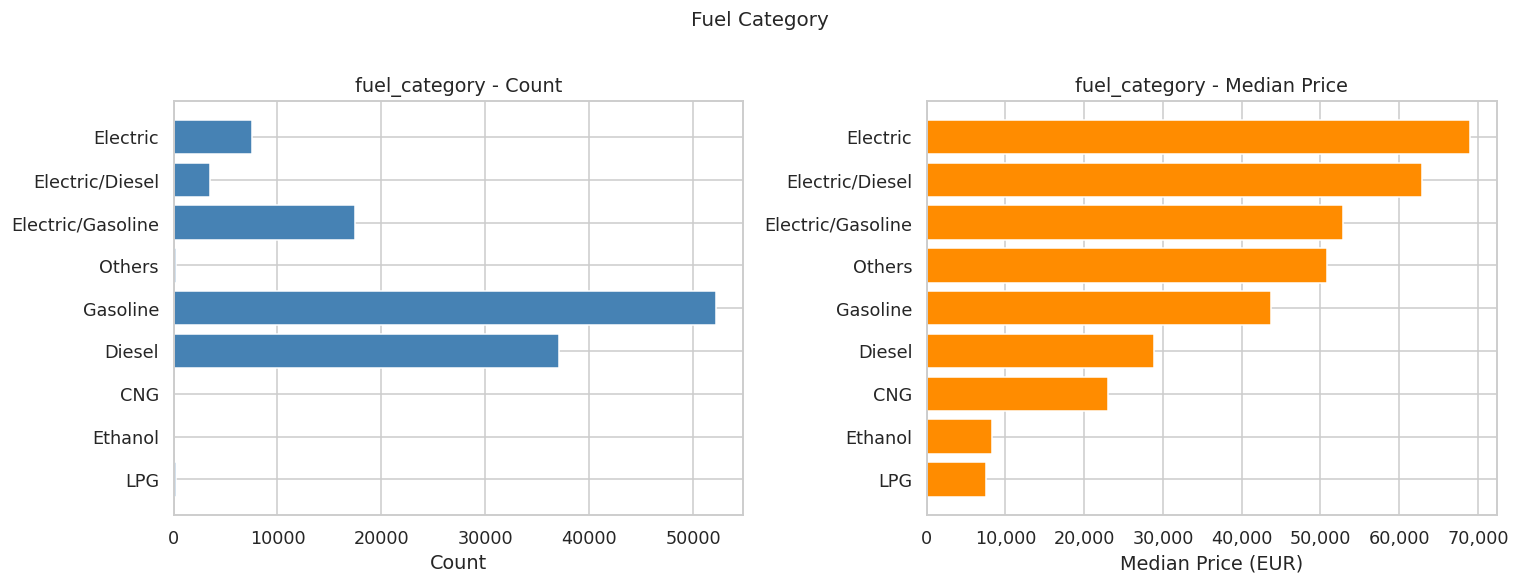

In [21]:
_ = cat_price_plot('fuel_category', title='Fuel Category')

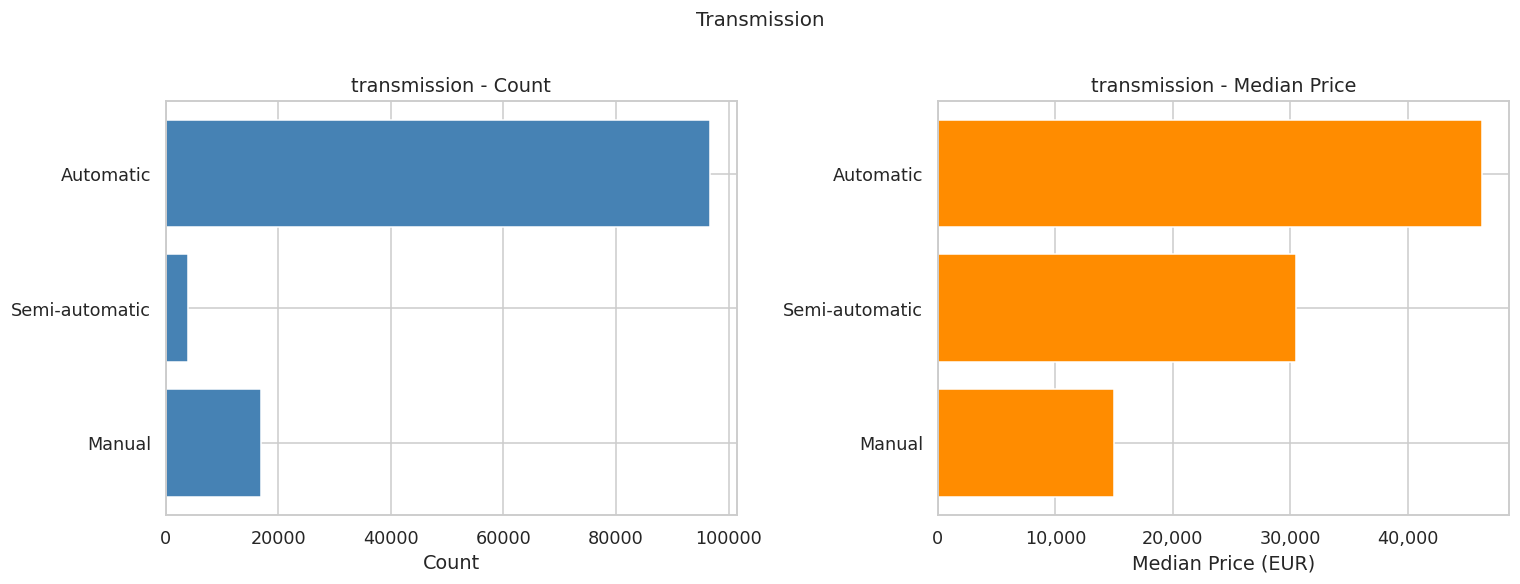

In [22]:
_ = cat_price_plot('transmission',  title='Transmission')

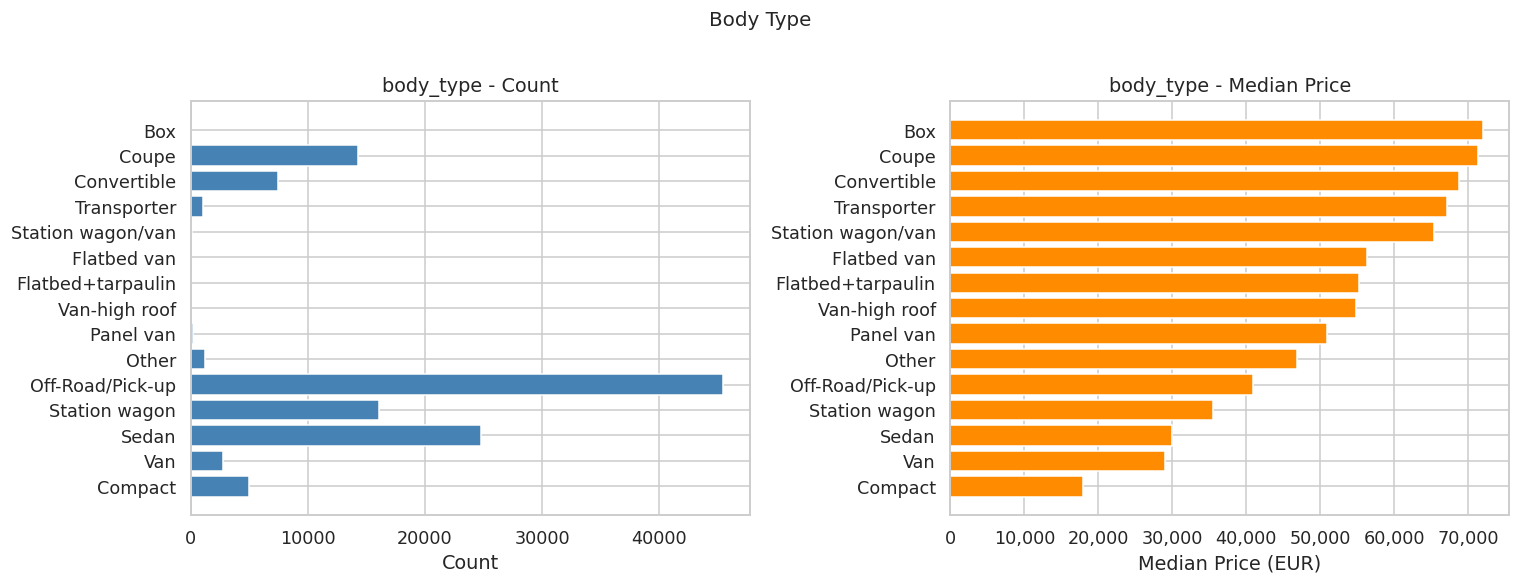

In [23]:
_ = cat_price_plot('body_type',     title='Body Type')

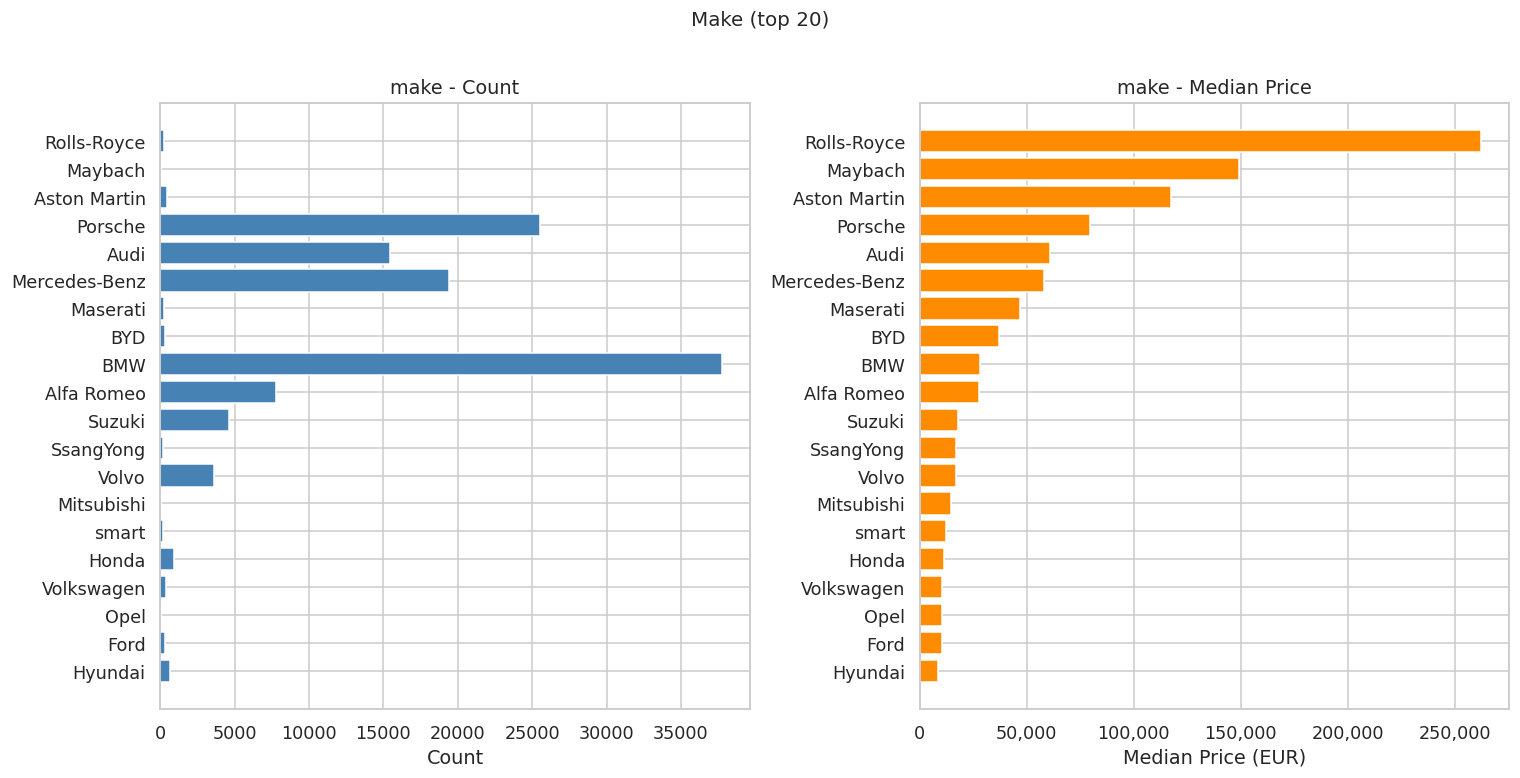

In [24]:
_ = cat_price_plot('make', top_n=20, title='Make (top 20)')

In [25]:
flag_cols = ['had_accident', 'has_full_service_history', 'non_smoking',
             'seller_is_dealer', 'has_warranty']
for col in flag_cols:
    if col not in df.columns:
        print(f'{col}: not found'); continue
    vc = df[col].value_counts(dropna=False)
    med = df.groupby(col)['price'].median().rename('median_price')
    print(f'\n{col}')
    print(pd.concat([vc, med], axis=1).to_string())


had_accident
               count  median_price
had_accident                      
False         118379       39980.0
True               3        8990.0

has_full_service_history
                          count  median_price
has_full_service_history                     
True                      66880       43710.0
False                     51502       35845.0

non_smoking
             count  median_price
non_smoking                     
False        61203       37990.0
True         57179       41999.0

seller_is_dealer
                  count  median_price
seller_is_dealer                     
True              98565       43995.0
False             19817       26499.0

has_warranty
               count  median_price
has_warranty                      
NaN           118382           NaN


In [26]:
print('nr_prev_owners:')
print(df['nr_prev_owners'].value_counts(dropna=False).head(15).to_string())
print(f"nr_prev_owners > 10 : {(df['nr_prev_owners'] > 10).sum():,}")

nr_prev_owners:
nr_prev_owners
NaN     53568
1.0     45972
2.0     13736
3.0      2974
0.0       951
4.0       730
5.0       264
6.0        92
7.0        39
8.0        24
9.0        11
10.0        8
12.0        6
11.0        3
24.0        2
nr_prev_owners > 10 : 13


## 5. Data Cleaning

In [27]:
df_clean = df.copy()
print(f'Start (after currency filter): {len(df_clean):,} rows')

Start (after currency filter): 118,382 rows


In [28]:
# Step 5.1: Drop columns > 70% missing (no signal)
miss_pct = df_clean.isna().mean()
high_miss_cols = miss_pct[miss_pct > 0.70].index.tolist()
print('Columns dropped (>70% missing):', high_miss_cols)
df_clean.drop(columns=high_miss_cols, inplace=True)

# Drop leakage / administrative / free-text columns
drop_cols = ['id', 'vin', 'german_hsn_tsn', 'street', 'zip', 'city',
             'latitude', 'longitude', 'seller_company_name',
             'description',             # used by NLP block
             'mileage_km_raw',          # redundant raw string
             'price_net',               # leakage (derived from price)
             'price_vat_rate',          # leakage
             'price_tax_deductible',    # leakage flag
             'price_negotiable',        # metadata
             'price_currency',          # constant after filter
             'warranty',                # free-text
             'offer_type',              # administrative
             'registration_date',       # replaced by production_year / car_age
            ]
drop_cols = [c for c in drop_cols if c in df_clean.columns]
print('Columns dropped (leakage / non-predictive):', drop_cols)
df_clean.drop(columns=drop_cols, inplace=True)
print(f'Columns remaining: {df_clean.shape[1]}')

Columns dropped (>70% missing): ['price_net', 'price_vat_rate', 'german_hsn_tsn', 'electric_range_km', 'electric_range_city_km', 'fuel_cons_city_l100_km', 'fuel_cons_highway_l100_km', 'co2_emission_grper_km', 'fuel_cons_comb_l100_wltp_km', 'fuel_cons_electric_comb_l100_wltp_km', 'has_warranty', 'warranty']
Columns dropped (leakage / non-predictive): ['id', 'vin', 'street', 'zip', 'city', 'latitude', 'longitude', 'seller_company_name', 'description', 'mileage_km_raw', 'price_tax_deductible', 'price_negotiable', 'price_currency', 'offer_type', 'registration_date']
Columns remaining: 48


In [29]:
# Step 5.2: Drop rows with missing target
before = len(df_clean)
df_clean.dropna(subset=['price'], inplace=True)
print(f'Dropped {before - len(df_clean):,} rows with missing price | Remaining: {len(df_clean):,}')

Dropped 0 rows with missing price | Remaining: 118,382


In [30]:
# Step 5.3: Price plausibility filter [500, 300_000]
# Rationale: <500 are likely errors/test listings; >150k are high-end outliers
#            that would distort the model for typical used cars.
PRICE_LOW, PRICE_HIGH = 500, 150_000
before = len(df_clean)
df_clean = df_clean[(df_clean['price'] >= PRICE_LOW) & (df_clean['price'] <= PRICE_HIGH)].copy()
print(f'Dropped {before - len(df_clean):,} rows outside price range | Remaining: {len(df_clean):,}')

Dropped 6,058 rows outside price range | Remaining: 112,324


In [31]:
# Step 5.4: production_year plausibility [1950, CURRENT_YEAR]
YEAR_LOW, YEAR_HIGH = 1950, CURRENT_YEAR
before = len(df_clean)
df_clean = df_clean[
    df_clean['production_year'].notna() &
    (df_clean['production_year'] >= YEAR_LOW) &
    (df_clean['production_year'] <= YEAR_HIGH)
].copy()
print(f'Dropped {before - len(df_clean):,} rows with impossible/missing year | Remaining: {len(df_clean):,}')

Dropped 117 rows with impossible/missing year | Remaining: 112,207


In [32]:
# Step 5.5: mileage_km cap (no rows dropped, just clip extreme values)
df_clean['mileage_km'] = df_clean['mileage_km'].clip(lower=0, upper=900_000)
print(f'mileage_km clipped to [0, 900,000] | Rows: {len(df_clean):,}')

mileage_km clipped to [0, 900,000] | Rows: 112,207


In [33]:
# Step 5.6: power_hp plausibility (drop <= 0, cap at 2000)
before = len(df_clean)
df_clean = df_clean[df_clean['power_hp'].isna() | (df_clean['power_hp'] > 0)].copy()
df_clean['power_hp'] = df_clean['power_hp'].clip(upper=2000)
print(f'Dropped {before - len(df_clean):,} rows with power_hp <= 0 | Remaining: {len(df_clean):,}')

Dropped 0 rows with power_hp <= 0 | Remaining: 112,207


In [34]:
# Step 5.7: Remove exact duplicate rows
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f'Dropped {before - len(df_clean):,} exact duplicate rows | Remaining: {len(df_clean):,}')

Dropped 2,811 exact duplicate rows | Remaining: 109,396


In [35]:
# Step 5.8: Impute remaining missing values
# Strategy:
#   Numeric    -> median (robust to skew, avoids mean distortion)
#   Categorical -> 'Unknown' (preserves missing as a learnable category)
remaining_miss = df_clean.isna().sum()
remaining_miss = remaining_miss[remaining_miss > 0].sort_values(ascending=False)
print('Missing before imputation:')
print(remaining_miss.to_string())

for col in df_clean.select_dtypes(include='number').columns:
    if df_clean[col].isna().any():
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

for col in df_clean.select_dtypes(include='object').columns:
    if df_clean[col].isna().any():
        df_clean[col].fillna('Unknown', inplace=True)

print(f'\nMissing after imputation: {df_clean.isna().sum().sum()}')
print(f'Rows after full cleaning : {len(df_clean):,}')

Missing before imputation:
fuel_cons_comb_l100_km          70122
original_market                 68103
co2_emission_grper_wltp_km      66562
primary_fuel                    53611
nr_prev_owners                  48373
body_color_original             41178
gears                           40350
ratings_count                   38138
ratings_average                 38138
ratings_recommend_percentage    38138
envir_standard                  37003
upholstery_color                29565
drive_train                     25934
upholstery                      23924
cylinders                       22516
paint_type                      22457
weight_kg                       21654
body_color                      11444
cylinders_volume_cc             11320
nr_seats                         4002
power_kw                         1416
power_hp                         1416
nr_doors                         1288
model                            1260
model_version                     760
transmission           

## 6. Feature Engineering

In [36]:
# car_age: more interpretable than raw year; avoids collinearity issues
df_clean['car_age'] = (CURRENT_YEAR - df_clean['production_year']).clip(lower=0).astype(int)
print('car_age stats:')
print(df_clean['car_age'].describe().round(1))

car_age stats:
count    109396.0
mean          6.4
std           5.7
min           0.0
25%           1.0
50%           6.0
75%           9.0
max          71.0
Name: car_age, dtype: float64


In [37]:
# mileage_per_year: normalises mileage by age (new car with 0 km vs old with 200k)
# Guard: if car_age == 0, mileage_per_year = mileage_km (it's a brand-new car)
df_clean['mileage_per_year'] = np.where(
    df_clean['car_age'] > 0,
    df_clean['mileage_km'] / df_clean['car_age'],
    df_clean['mileage_km']
)
df_clean['mileage_per_year'] = df_clean['mileage_per_year'].clip(0, 200_000)
print('mileage_per_year stats:')
print(df_clean['mileage_per_year'].describe().round(1))

mileage_per_year stats:
count    109396.0
mean      11571.7
std        8362.9
min           0.0
25%        6250.0
50%       10416.9
75%       15606.7
max      200000.0
Name: mileage_per_year, dtype: float64


In [38]:
# Encoding plan (to be applied at modelling time in notebook 02)
# LOW cardinality (<= 20 unique)  -> One-Hot Encoding (OHE)
# HIGH cardinality (> 20 unique)  -> Target / Frequency Encoding
low_card, high_card = [], []
for col in df_clean.select_dtypes(include='object').columns:
    n = df_clean[col].nunique()
    (low_card if n <= 20 else high_card).append((col, n))

print('LOW-CARDINALITY (OHE at modelling time):')
for c, n in sorted(low_card, key=lambda x: x[1]):
    print(f'  {c}: {n} unique')

print('\nHIGH-CARDINALITY (frequency/target encoding at modelling time):')
for c, n in sorted(high_card, key=lambda x: -x[1]):
    print(f'  {c}: {n} unique')

LOW-CARDINALITY (OHE at modelling time):
  vehicle_type: 2 unique
  paint_type: 3 unique
  seller_type: 3 unique
  transmission: 4 unique
  drive_train: 4 unique
  upholstery: 7 unique
  country_code: 9 unique
  fuel_category: 10 unique
  upholstery_color: 12 unique
  envir_standard: 12 unique
  body_color: 15 unique
  primary_fuel: 15 unique
  body_type: 18 unique

HIGH-CARDINALITY (frequency/target encoding at modelling time):
  model_version: 79813 unique
  equipment_comfort: 70433 unique
  equipment_safety: 50763 unique
  equipment_extra: 46765 unique
  body_color_original: 10228 unique
  equipment_entertainment: 6499 unique
  model: 600 unique
  original_market: 34 unique
  make: 25 unique


In [39]:
# Drop power_kw (redundant with power_hp; hp is the common industry metric)
drop_eng = ['power_kw']
drop_eng = [c for c in drop_eng if c in df_clean.columns]
df_clean.drop(columns=drop_eng, inplace=True)
print('Dropped redundant columns:', drop_eng)
print(f'Final feature set: {df_clean.shape[1]} columns, {len(df_clean):,} rows')
print()
print(df_clean.dtypes.to_string())

Dropped redundant columns: ['power_kw']
Final feature set: 49 columns, 109,396 rows

ratings_average                 float64
ratings_count                   float64
ratings_recommend_percentage    float64
price                           float64
make                             object
model                            object
model_version                    object
mileage_km                      float64
production_year                 float64
vehicle_type                     object
body_type                        object
nr_seats                        float64
nr_doors                        float64
body_color                       object
paint_type                       object
body_color_original              object
upholstery                       object
upholstery_color                 object
power_hp                        float64
transmission                     object
gears                           float64
drive_train                      object
cylinders                       flo

In [40]:
df_clean.to_csv(CLEAN_CSV, index=False)
print(f'Saved: {CLEAN_CSV}')
print(f'Shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns')

Saved: ../data/autoscout_clean.csv
Shape: 109,396 rows x 49 columns


## 7. Train/Validation/Test Split Strategy (DEFINE ONLY)

In [41]:
from sklearn.model_selection import train_test_split

# 80 / 10 / 10  train / val / test,  random_state = 42
# - 80% train  : main learning set for model fitting
# - 10% val    : held out for hyperparameter tuning & model selection
# - 10% test   : strictly held out; touched only once for final evaluation
# Simple random shuffle is sufficient (price is continuous, no strong time trend).
# No model is trained here.

df_trainval, df_test = train_test_split(df_clean, test_size=0.10,
                                         random_state=RANDOM_STATE, shuffle=True)
df_train, df_val     = train_test_split(df_trainval, test_size=(0.10 / 0.90),
                                         random_state=RANDOM_STATE, shuffle=True)

print(f'Train : {len(df_train):,} rows ({len(df_train)/len(df_clean)*100:.1f}%)')
print(f'Val   : {len(df_val):,} rows ({len(df_val)/len(df_clean)*100:.1f}%)')
print(f'Test  : {len(df_test):,} rows ({len(df_test)/len(df_clean)*100:.1f}%)')

# Save split index files
df_train.index.to_series().to_csv(DATA_DIR / 'split_train_idx.csv', index=False)
df_val.index.to_series().to_csv(DATA_DIR   / 'split_val_idx.csv',   index=False)
df_test.index.to_series().to_csv(DATA_DIR  / 'split_test_idx.csv',  index=False)
print('Split indices saved to data/split_*_idx.csv')

Train : 87,516 rows (80.0%)
Val   : 10,940 rows (10.0%)
Test  : 10,940 rows (10.0%)
Split indices saved to data/split_*_idx.csv


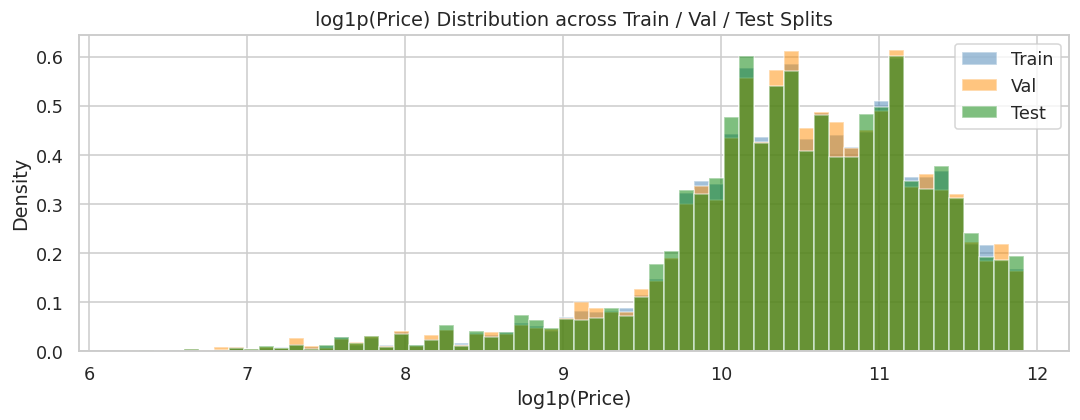

In [42]:
# Sanity check: price distribution should be consistent across all three splits
fig, ax = plt.subplots(figsize=(10, 4))
for split_df, label, color in [
        (df_train, 'Train', 'steelblue'),
        (df_val,   'Val',   'darkorange'),
        (df_test,  'Test',  'green')]:
    ax.hist(np.log1p(split_df['price']), bins=60, alpha=0.5,
            label=label, color=color, density=True)
ax.set_title('log1p(Price) Distribution across Train / Val / Test Splits')
ax.set_xlabel('log1p(Price)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Key EDA Findings

In [43]:
ch_n  = int((df['country_code'] == 'CH').sum())
tot_n = len(df)
n_raw   = len(df_raw)
n_clean = len(df_clean)

corr_power = df_clean[['power_hp', 'price']].corr().loc['power_hp', 'price']
corr_mile  = df_clean[['mileage_km', 'price']].corr().loc['mileage_km', 'price']
corr_year  = df_clean[['production_year', 'price']].corr().loc['production_year', 'price']

print(f"""
=== KEY EDA FINDINGS ===

1. DATASET SIZE
   {n_raw:,} raw rows -> {n_clean:,} clean rows ({n_clean/n_raw*100:.1f}% retained).
   Main losses: impossible/missing production years, price outliers.

2. CURRENCY
   Dominant currency: {dominant_currency}.
   {int((df_raw['price_currency'] == dominant_currency).sum()):,} rows kept;
   {int((df_raw['price_currency'] != dominant_currency).sum()):,} rows with other currencies dropped.
   No currency conversion attempted.

3. COUNTRY SCOPE  [FLAG FOR REVIEW]
   Switzerland (CH): {ch_n:,} rows ({ch_n/tot_n*100:.1f}% of currency-filtered set).
   {'CH-only model viable (>= 5,000 rows).' if ch_n >= 5000 else 'CH alone too small; recommend full European set.'}
   Full European set: {tot_n:,} rows.
   Confirm scope (CH-only vs full Europe) before model training!

4. PRICE DISTRIBUTION
   Right-skewed (skew={df['price'].skew():.2f}). log1p transform recommended.
   Plausibility range: [{PRICE_LOW:,} - {PRICE_HIGH:,}] {dominant_currency}.

5. STRONGEST POSITIVE PREDICTOR
   power_hp (Pearson r = {corr_power:.3f}): engine power is the dominant numeric driver.

6. STRONGEST NEGATIVE PREDICTORS
   mileage_km (r = {corr_mile:.3f}) and production_year (r = {corr_year:.3f}).
   Higher mileage and older cars are cheaper, as expected.

7. KEY CATEGORICAL SIGNALS
   Transmission: automatic >> manual on median price.
   Fuel: electric/hybrid > petrol > diesel for newer listings.
   Make: strong predictor (luxury vs mass-market gap is large).

8. DATA QUALITY ISSUES
   - production_year mostly stored in registration_date (extracted as fallback).
   - mileage_km / weight_kg were string columns ('10,500 km') -> parsed to numeric.
   - mileage_km = 0 on used cars (retained; may be pre-registered demos).
   - had_accident / non_smoking sparse -> imputed as 'Unknown'.

9. ENGINEERED FEATURES
   car_age       = {CURRENT_YEAR} - production_year (clipped >= 0).
   mileage_per_year = mileage_km / car_age (div-zero guarded, capped at 200,000).

10. SPLIT
    80/10/10 train/val/test, random_state=42.
    Indices saved to data/split_*_idx.csv.
""")


=== KEY EDA FINDINGS ===

1. DATASET SIZE
   118,382 raw rows -> 109,396 clean rows (92.4% retained).
   Main losses: impossible/missing production years, price outliers.

2. CURRENCY
   Dominant currency: EUR.
   118,382 rows kept;
   0 rows with other currencies dropped.
   No currency conversion attempted.

3. COUNTRY SCOPE  [FLAG FOR REVIEW]
   Switzerland (CH): 0 rows (0.0% of currency-filtered set).
   CH alone too small; recommend full European set.
   Full European set: 118,382 rows.
   Confirm scope (CH-only vs full Europe) before model training!

4. PRICE DISTRIBUTION
   Right-skewed (skew=48.44). log1p transform recommended.
   Plausibility range: [500 - 150,000] EUR.

5. STRONGEST POSITIVE PREDICTOR
   power_hp (Pearson r = 0.686): engine power is the dominant numeric driver.

6. STRONGEST NEGATIVE PREDICTORS
   mileage_km (r = -0.545) and production_year (r = 0.422).
   Higher mileage and older cars are cheaper, as expected.

7. KEY CATEGORICAL SIGNALS
   Transmission: au